# Midterm Exam (part 2) - Computational Physics I

### Date: Thursday 3 April 2025
### Credits: 10 points

### Duration: 1 hour

## Name: Juan Daniel Vasconez

### Instructions:

- When you finish, please send me the **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The exam is individual. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems:

## 5. I/O and regression: Larmor precession (5 points) 

This problem consists of analysing the relationship between magnetic field strength and Larmor precession frequency, a fundamental principle in Nuclear Magnetic Resonance (NMR). To this end, a simulated dataset was generated, mimicking experimental measurements, and stored in a CSV file. This dataset contains pairs of values: **magnetic field strength (in Tesla)** and the corresponding observed **Larmor frequency (in Hertz)**. The goal is to investigate the relationship predicted by the **Larmor equation**.

#### Data:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/larmor_precession_data.csv

a) Create a pandas-based python I/O function that opens the above data file and returns $2$ arrays, one for the magnetic field strength and one for the Larmor frequency.

b) Call your I/O function and make a high-quality labeled plot of Larmor frequency (in the Y axis) versus magnetic field strength (in the X axis).

c) Write down and use a physical model (motivated by quantum mechanics) to carry out a regression and constrain any free parameters in the model.

d) Report the results from your regression, i.e. the best-fit value for the free parameter/s with respective uncertainty/ies.

e) Make a plot showing the empirical data and the best-fit model obtained from your regression.  Based on your analysis, can you infer the particle assumed for the simulated data?


##### Reference for Larmor precession: https://github.com/wbandabarragan/quantum-mechanics-1/blob/main/unit-4/Lecture-Notes-UC4.pdf

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import numpy as np
import scipy.stats as st
from PIL import Image

Larmor Precession is the precession of the magnetic moment of an object about an external magnetic field. Where the torque is defined as:

$$
\vec{\tau} = \vec{\mu} \times \vec{B} = \gamma \vec{J} \times \vec{B}

$$

where $\vec{\tau }$ is the torque, $\vec {\mu }$ is the magnetic dipole moment, $\vec {J}$ is the angular momentum vector, $\vec {B}$ is the external magnetic field.

The angular momentum vector $\vec{J}$ precesses about external fields with an angular frequency known as the Larmor Frecuency defined as:

$$
\omega = |\gamma B|
$$
where $\omega$ is the angular frequency, B is the magnitude of the applied magnetic field, and γ $\gamma$ is the gyromagnetic ratio. Being this our model to fit.

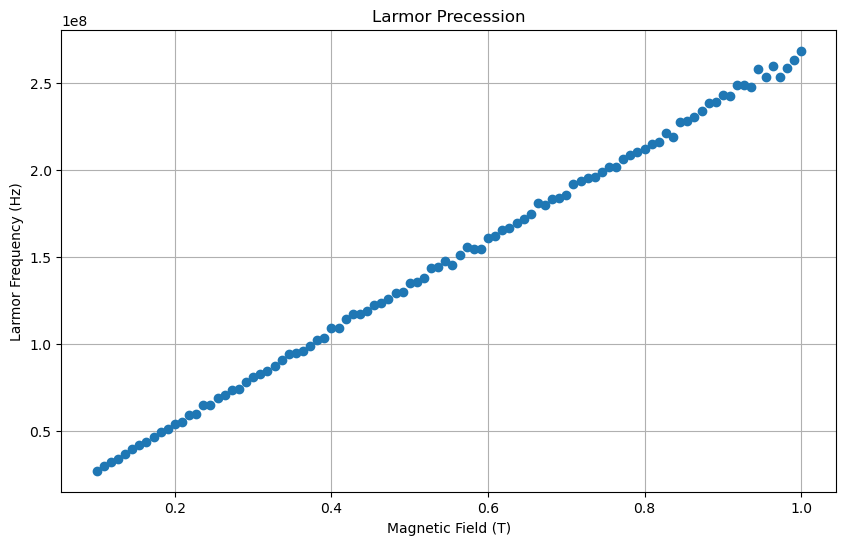

In [3]:
def data(filename):
    """
    This function reads a file and returns its contents.
    
    :param filename: The name of the file to read
    :return: The contents of the file
    """
    df = pd.read_csv(filename)
    b = df['B (Tesla)'].to_numpy()
    lf = df['Frequency (Hz)'].to_numpy()
    
    return b, lf

b, lf = data('./larmor_precession_data.csv')


plt.figure(figsize=(10, 6))
plt.plot(b, lf, 'o', label='Data')
plt.xlabel('Magnetic Field (T)')
plt.ylabel('Larmor Frequency (Hz)')
plt.title('Larmor Precession')
plt.grid()
plt.show()


Here we can denote the linear realation between our two variables. Making us able to do a good regression. Lets check our Pearson and Spearman Coefs

In [4]:
p = st.pearsonr(b, lf)
print(f'Pearson correlation coefficient: {p[0]}')
sp = st.spearmanr(b, lf)
print(f'Spearman correlation coefficient: {sp[0]}')


Pearson correlation coefficient: 0.9997109287021749
Spearman correlation coefficient: 0.9997599759975996


Since we have a strong relation between our variables. lets define a model to fit. And fit the function based on the data using Curve Fit

In [23]:
def fit_model(x, m , b):
    """
    This function defines a linear model for fitting.
    
    :param x: The independent variable
    :param m: The slope of the line
    :param b: The y-intercept of the line
    :return: The dependent variable
    """
    y = m * x + b
    return y

coef, cova = opt.curve_fit(fit_model, b, lf)
gamma, b_fit = coef



err = np.sqrt(np.diag(cova))

print(err)
print('FItted Gamma is:')
print("{:.7e}".format(gamma)  + ' [Rad * Hz/T]')
print("Error in gamma is %.8e" % (err[0]) + ' [Rad * Hz/T]')

print("\n")
print('Fitted intercept is:')
print("{:.4e}".format(b_fit))
print("Error in intercetp is %.5f" % (err[1]))
print("\n")


print(f'Correlation coefficient: {np.corrcoef(b, lf)[0, 1]}')
print(f'The resulting Fit function is: Larmor Frequency = {gamma} * Magnetic Field + {b_fit}')

y = fit_model(b, gamma, b_fit)



[648047.88737561 394918.53694624]
FItted Gamma is:
2.6675293e+08 [Rad * Hz/T]
Error in gamma is 6.48047887e+05 [Rad * Hz/T]


Fitted intercept is:
2.3013e+05
Error in intercetp is 394918.53695


Correlation coefficient: 0.9997109287021748
The resulting Fit function is: Larmor Frequency = 266752928.88981372 * Magnetic Field + 230129.4038747102


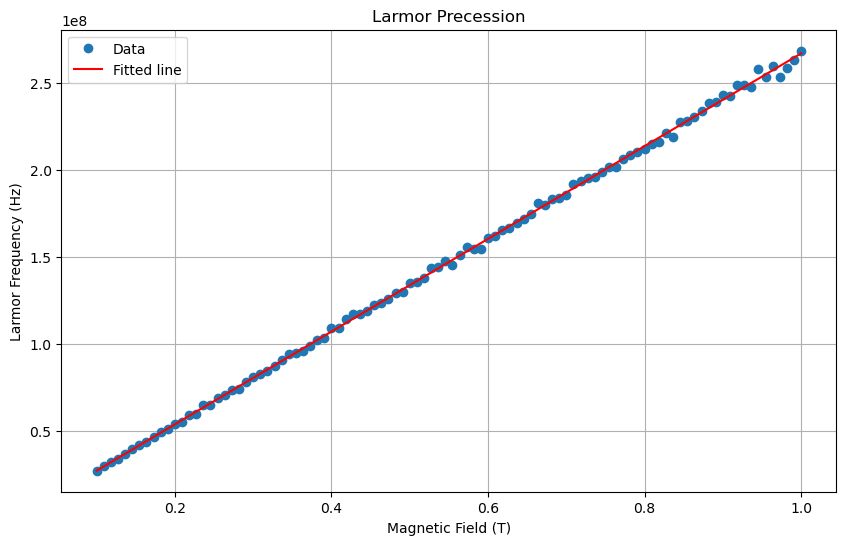

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(b, lf, 'o', label='Data')
plt.plot(b, y, 'r-', label='Fitted line')
plt.xlabel('Magnetic Field (T)')
plt.ylabel('Larmor Frequency (Hz)')
plt.title('Larmor Precession')
plt.legend()
plt.grid()
plt.show()

Where, from this table found on wikipedia.
Source: https://en.wikipedia.org/wiki/Gyromagnetic_ratio

 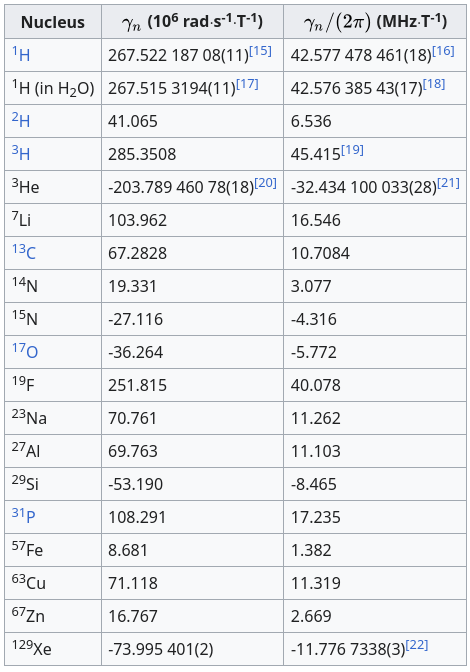


We can infer that based on the gyromagnetic ratio. Our particle is Hydrogen

## 6. Image processing: Scanning Electron Microscope of Escherichia coli (5 points)

This problem consists of analysing the reduction of the **bacteria Escherichia coli (E. coli)** after treatment with **Zinc oxide (ZnO) nanoparticles**. The images provided below were obtained from a **Scanning Electron Microscope (SEM)**, before and after 5 hours of treatment with ZnO. One pixel of  the image has an area of $0.02^2\mu m^2$.

#### SEM image before ZnO treatment:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_before.jpg

#### SEM image after ZnO treatment:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_after.jpg

To analyse how effective this antibacterial treatment is, carry out the following analysis in python:

a) Create a python function that reads in an image file and returns one its channels as an array.

b) Call your function from (a), and:

- Make a 2-panel figure showing the before and after SEM images.
- Make a 2-panel figure showing the before and after pixel histograms of the SEM images.

c) Create a python function that isolates the area covered by the E. coli bacteria from the background. Your function should read in an image channel array and return a cleaned binary image array with zeroes in the background and ones in the E. coli area.

d) Call your function from (c), and:

- Make a 2-panel figure showing the before and after binary images.
- Make a 2-panel figure showing the before and after pixel histograms of the binary images.

e) Using your binary images, calculate the following:

- The total area in pixels and physical units covered by the E. coli bateria before and after treatment.
- The ratio between such areas, how effective is the antibacterial treatment with ZnO nanoparticles?

##### SEM images reference: Zhang et al. 2007, https://link.springer.com/article/10.1007/s11051-006-9150-1

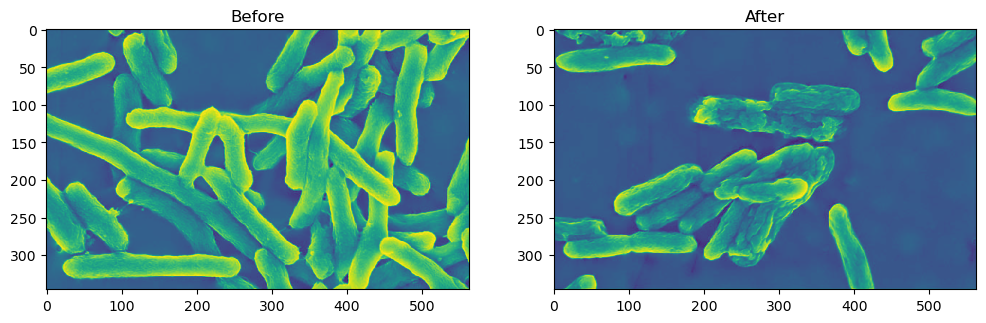

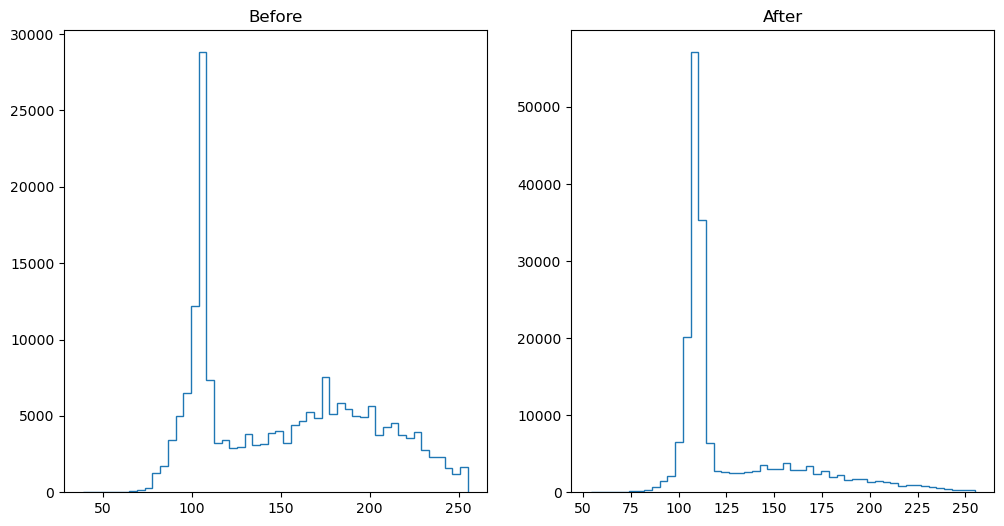

In [48]:
def image_channels(filename):
    """
    This function reads an image and returns
    the channels of the image.
    """
    img = plt.imread(filename)
    return img[:,:, 0]

after = image_channels('./bacteria_after.jpg')
before = image_channels('./bacteria_before.jpg')


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(before)
ax[0].set_title('Before')
ax[1].imshow(after)
ax[1].set_title('After')
plt.show()

before1D = np.reshape(before, (before.size, 1))
after1D = np.reshape(after, (after.size, 1))

fig , ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(before1D, histtype = "step", bins = 50)
ax[0].set_title('Before')
ax[1].hist(after1D, histtype = "step", bins = 50)
ax[1].set_title('After')
plt.show()

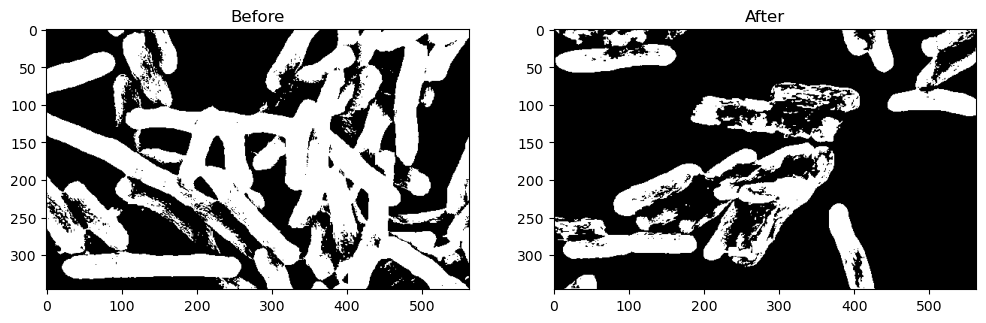

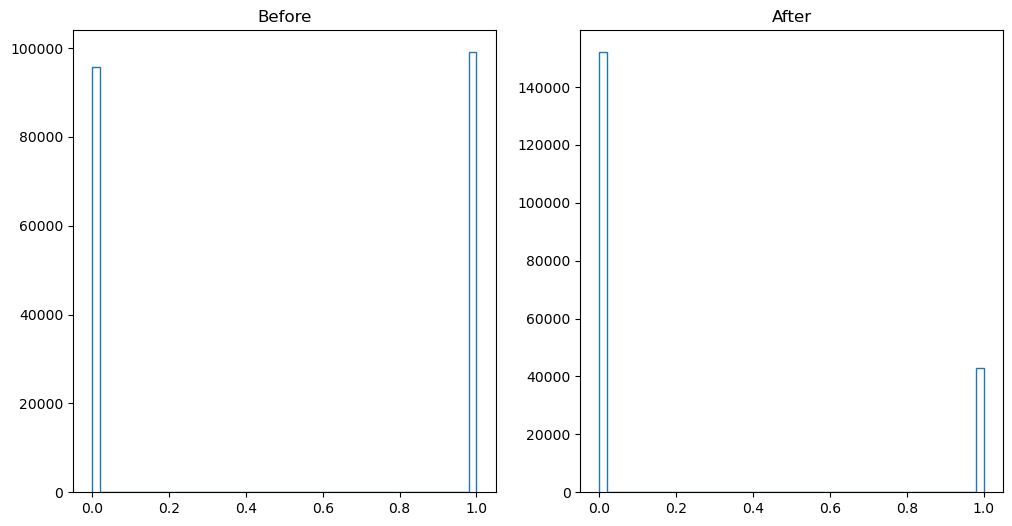

In [52]:
def clean_image_data(before, after, threshold=150):
    """
    This function reshapes the before and after images into 1D arrays
    and applies a threshold to create binary cleaned arrays.

    :param before: numpy.ndarray, the 'before' image data
    :param after: numpy.ndarray, the 'after' image data
    :param threshold: int, the threshold value for cleaning
    :return: tuple of numpy.ndarrays, cleaned 2D arrays for before and after images
    """
    after_clean = np.where(after < threshold, 0., 1.)
    before_clean = np.where(before < threshold, 0., 1.)
    return before_clean, after_clean

before_clean, after_clean = clean_image_data(before, after)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(before_clean, cmap='gray')
ax[0].set_title('Before')
ax[1].imshow(after_clean, cmap='gray')
ax[1].set_title('After')
plt.show()

before_clean1D = np.reshape(before_clean, (before_clean.size, 1))
after_clean1D = np.reshape(after_clean, (after_clean.size, 1))

fig , ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(before_clean1D, histtype = "step", bins = 50)
ax[0].set_title('Before')
ax[1].hist(after_clean1D, histtype = "step", bins = 50)
ax[1].set_title('After')
plt.show()


In [ ]:

pixel_area = 0.02**2


area_before = np.sum(before_clean) * pixel_area
area_after = np.sum(after_clean) * pixel_area

print(f"Total area covered by bacteria before treatment: {area_before:.2f} µm²")
print(f"Total area covered by bacteria after treatment: {area_after:.2f} µm²")

ratio = area_after / area_before
print(f"Ratio of area after to area before: {ratio:.2f}")
print(f"Percentage of area covered by bacteria after treatment: {ratio * 100:.2f}%")

Total area covered by bacteria before treatment: 39.61 µm²
Total area covered by bacteria after treatment: 17.13 µm²
Ratio of area after to area before: 0.43
Percentage of area covered by bacteria after treatment: 43.23%
